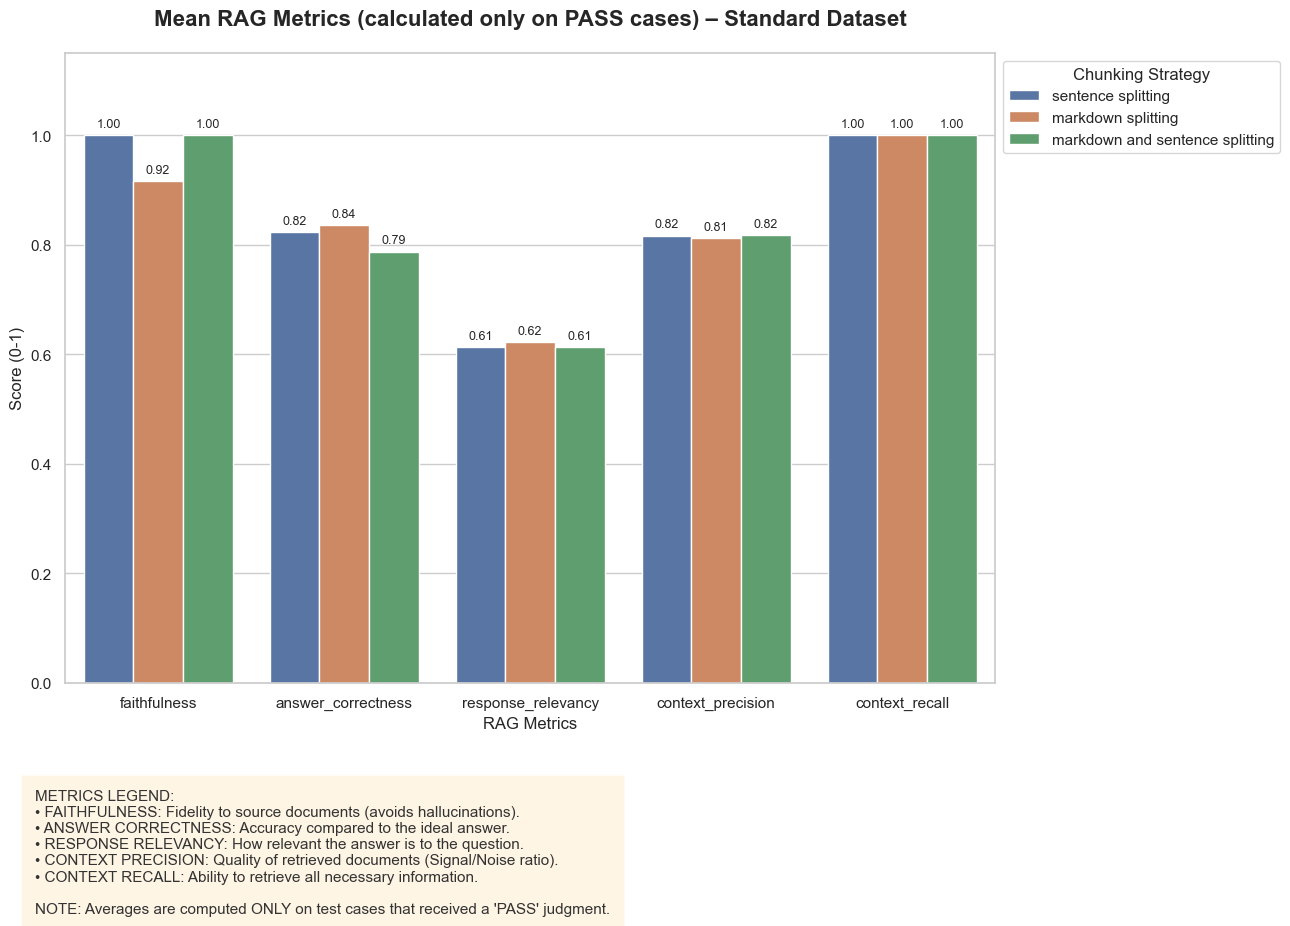

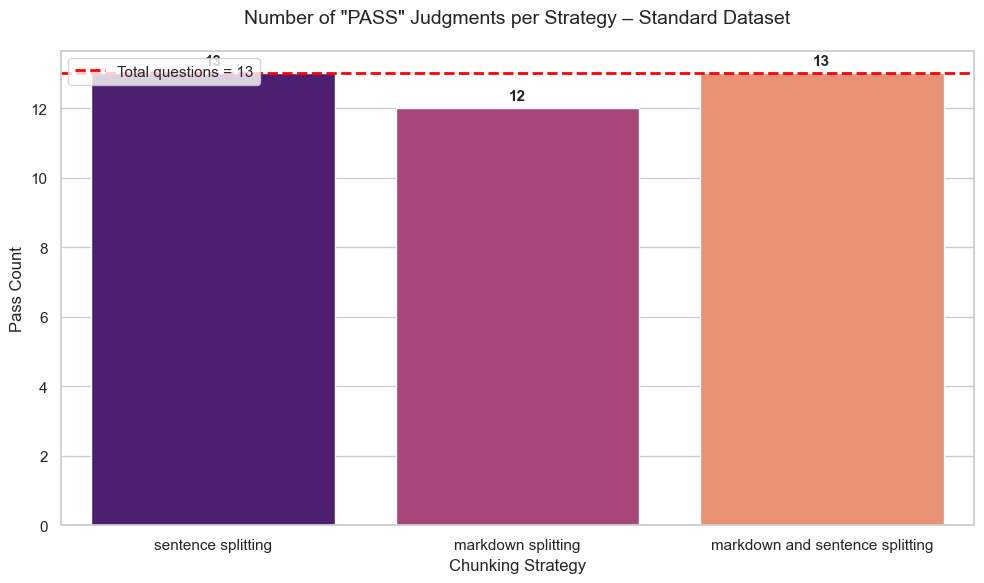


--- SUMMARY JUDGE PASS COUNT (Standard) ---
sentence splitting: 13 pass / 13 total (rate: 100.0%)
markdown splitting: 12 pass / 13 total (rate: 92.3%)
markdown and sentence splitting: 13 pass / 13 total (rate: 100.0%)

--- TEXTUAL DATA SUMMARY – METRICS AVERAGED ON PASS CASES ONLY (Standard) ---
SENTENCE SPLITTING: faithfulness: 1.000, answer_correctness: 0.823, response_relevancy: 0.613, context_precision: 0.817, context_recall: 1.000
MARKDOWN SPLITTING: faithfulness: 0.917, answer_correctness: 0.835, response_relevancy: 0.622, context_precision: 0.812, context_recall: 1.000
MARKDOWN AND SENTENCE SPLITTING: faithfulness: 1.000, answer_correctness: 0.787, response_relevancy: 0.613, context_precision: 0.818, context_recall: 1.000




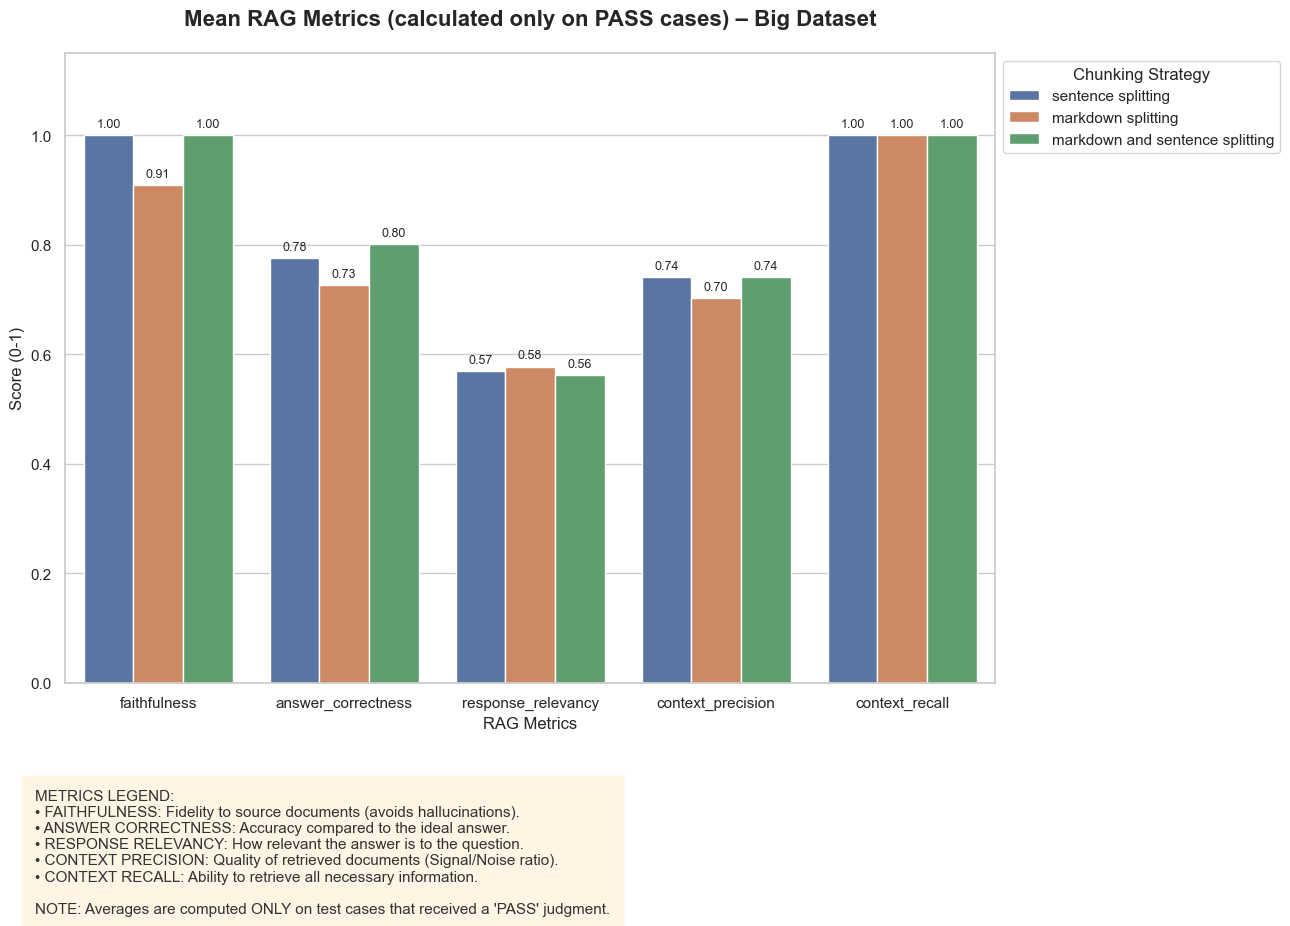

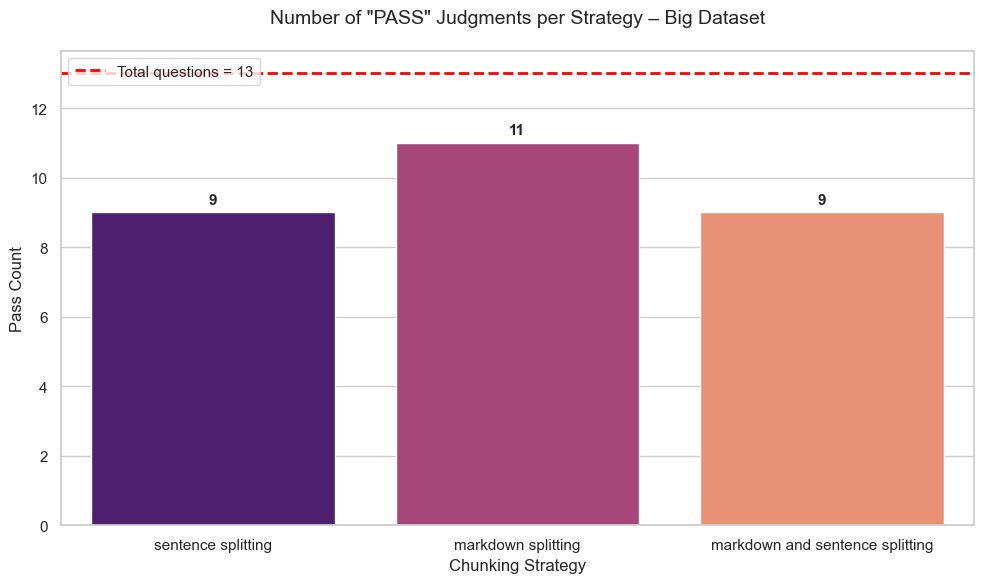


--- SUMMARY JUDGE PASS COUNT (Big) ---
sentence splitting: 9 pass / 13 total (rate: 69.2%)
markdown splitting: 11 pass / 13 total (rate: 84.6%)
markdown and sentence splitting: 9 pass / 13 total (rate: 69.2%)

--- TEXTUAL DATA SUMMARY – METRICS AVERAGED ON PASS CASES ONLY (Big) ---
SENTENCE SPLITTING: faithfulness: 1.000, answer_correctness: 0.775, response_relevancy: 0.570, context_precision: 0.741, context_recall: 1.000
MARKDOWN SPLITTING: faithfulness: 0.909, answer_correctness: 0.726, response_relevancy: 0.577, context_precision: 0.703, context_recall: 1.000
MARKDOWN AND SENTENCE SPLITTING: faithfulness: 1.000, answer_correctness: 0.802, response_relevancy: 0.562, context_precision: 0.741, context_recall: 1.000




In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
name_map = {
    'from_index_sentence_results': 'sentence splitting',
    'from_index_markdown_chunking_results': 'markdown splitting',
    'from_index_markdown_and_sentence_results': 'markdown and sentence splitting'
}

metrics = ['faithfulness', 'answer_correctness', 'response_relevancy', 'context_precision', 'context_recall']

# ------------------------------------------------------------
# Function to process a set of experiments and generate plots
# ------------------------------------------------------------
def process_experiment_set(file_list, dataset_name):
    """
    file_list: list of CSV file paths
    dataset_name: string, e.g. "Standard" or "Big"
    """
    results = []
    pass_counts = []
    
    for file_path in file_list:
        raw_name = os.path.basename(file_path).replace('.csv', '')
        base_name = raw_name.replace('_big', '')
        label = name_map.get(base_name, base_name)
        
        try:
            df = pd.read_csv(file_path)
            
            # ---- Pass count statistics (on full data) ----
            if 'judge_result' in df.columns:
                n_pass = (df['judge_result'] == 'pass').sum()
                n_total = len(df)
                pass_counts.append({
                    'strategy': label,
                    'pass_count': n_pass,
                    'total': n_total,
                    'pass_rate': n_pass / n_total if n_total > 0 else 0
                })
                
                # ---- Metrics: compute ONLY on rows where judge_result == 'pass' ----
                df_pass = df[df['judge_result'] == 'pass']
                if len(df_pass) > 0:
                    row = df_pass[metrics].mean().to_dict()
                else:
                    # No passes -> all metrics set to NaN (will appear as gaps in plot)
                    row = {m: np.nan for m in metrics}
                row['strategy'] = label
                results.append(row)
            else:
                print(f"Warning: {label} ({dataset_name}) has no 'judge_result' column – using all rows for metrics")
                # Fallback: use all rows
                row = df[metrics].mean().to_dict()
                row['strategy'] = label
                results.append(row)
                # No pass count information
                
        except Exception as e:
            print(f"Error processing {label} ({dataset_name}): {e}")
    
    if not results:
        print(f"No data for {dataset_name}")
        return
    
    df_results = pd.DataFrame(results)
    df_pass = pd.DataFrame(pass_counts) if pass_counts else None
    
    # ---------- Plot 1: Mean RAG metrics (only on PASS cases) ----------
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 10))
    df_melted = df_results.melt(id_vars='strategy', value_vars=metrics, var_name='Metric', value_name='Score')
    # Drop NaN values from melted df so they don't appear in the plot
    df_melted_clean = df_melted.dropna(subset=['Score'])
    
    ax1 = sns.barplot(data=df_melted_clean, x='Metric', y='Score', hue='strategy')
    
    plt.title(f'Mean RAG Metrics (calculated only on PASS cases) – {dataset_name} Dataset', 
              fontsize=16, pad=20, fontweight='bold')
    plt.ylim(0, 1.15)
    plt.ylabel('Score (0-1)', fontsize=12)
    plt.xlabel('RAG Metrics', fontsize=12)
    plt.legend(title='Chunking Strategy', bbox_to_anchor=(1, 1), loc='upper left')
    
    for p in ax1.patches:
        if p.get_height() > 0:
            ax1.annotate(f"{p.get_height():.2f}", 
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 8), 
                         textcoords='offset points', fontsize=9)
    
    description_text = (
        "METRICS LEGEND:\n"
        "• FAITHFULNESS: Fidelity to source documents (avoids hallucinations).\n"
        "• ANSWER CORRECTNESS: Accuracy compared to the ideal answer.\n"
        "• RESPONSE RELEVANCY: How relevant the answer is to the question.\n"
        "• CONTEXT PRECISION: Quality of retrieved documents (Signal/Noise ratio).\n"
        "• CONTEXT RECALL: Ability to retrieve all necessary information.\n\n"
        "NOTE: Averages are computed ONLY on test cases that received a 'PASS' judgment."
    )
    
    plt.figtext(0.1, 0.02, description_text, fontsize=11, color="#333333", 
                bbox={"facecolor":"orange", "alpha":0.1, "pad":10}, 
                horizontalalignment='left')
    plt.subplots_adjust(bottom=0.25)  # Slightly more space for the longer note
    plt.show()
    
    # ---------- Plot 2: Pass count with horizontal line ----------
    if df_pass is not None:
        total_questions = df_pass['total'].iloc[0]
        plt.figure(figsize=(10, 6))
        ax2 = sns.barplot(data=df_pass, x='strategy', y='pass_count', 
                          hue='strategy', palette='magma', legend=False)
        ax2.axhline(y=total_questions, color='red', linestyle='--', linewidth=2,
                    label=f'Total questions = {total_questions}')
        plt.title(f'Number of "PASS" Judgments per Strategy – {dataset_name} Dataset', 
                  fontsize=14, pad=20)
        plt.ylabel('Pass Count')
        plt.xlabel('Chunking Strategy')
        plt.legend(loc='upper left')
        
        for p in ax2.patches:
            ax2.annotate(f"{int(p.get_height())}", 
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 9), 
                         textcoords='offset points', fontsize=11, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Print summary
        print(f"\n--- SUMMARY JUDGE PASS COUNT ({dataset_name}) ---")
        for _, r in df_pass.iterrows():
            print(f"{r['strategy']}: {int(r['pass_count'])} pass / {r['total']} total (rate: {r['pass_rate']:.1%})")
    else:
        print(f"No 'judge_result' data found for {dataset_name}")
    
    # Print metric summary (only on passes)
    print(f"\n--- TEXTUAL DATA SUMMARY – METRICS AVERAGED ON PASS CASES ONLY ({dataset_name}) ---")
    for _, r in df_results.iterrows():
        metrics_str = ", ".join([f"{m}: {r[m]:.3f}" for m in metrics if pd.notna(r[m])])
        print(f"{r['strategy'].upper()}: {metrics_str}")
    print("\n" + "="*80 + "\n")

# ------------------------------------------------------------
# Define file lists for the two experiment sets
# ------------------------------------------------------------
normal_files = [
    'evals/experiments/from_index_sentence_results.csv',
    'evals/experiments/from_index_markdown_chunking_results.csv',
    'evals/experiments/from_index_markdown_and_sentence_results.csv'
]

big_files = [
    'evals/experiments/from_index_sentence_big_results.csv',
    'evals/experiments/from_index_markdown_chunking_big_results.csv',
    'evals/experiments/from_index_markdown_and_sentence_big_results.csv'
]

# ------------------------------------------------------------
# Run for both datasets
# ------------------------------------------------------------
process_experiment_set(normal_files, "Standard")
process_experiment_set(big_files, "Big")